# Étapes Préparatoires

In [5]:
# Algèbre linéaire
import numpy as np

# Manipulation de données
import pandas as pd

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/alexandremasse21/testmnist-csv/test.csv
/kaggle/input/datasets/alexandremasse21/trainmnist-csv/train.csv


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Dropout, Flatten
from tensorflow.keras.utils import to_categorical

In [30]:
train = pd.read_csv("/kaggle/input/datasets/alexandremasse21/trainmnist-csv/train.csv")
test = pd.read_csv("/kaggle/input/datasets/alexandremasse21/testmnist-csv/test.csv")

print("Train shape: ", train.shape)
print("Test shape: ", test.shape)

Train shape:  (42000, 785)
Test shape:  (28000, 784)


In [8]:
train.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [9]:
train["label"].value_counts().sort_index()

label
0    4132
1    4684
2    4177
3    4351
4    4072
5    3795
6    4137
7    4401
8    4063
9    4188
Name: count, dtype: int64

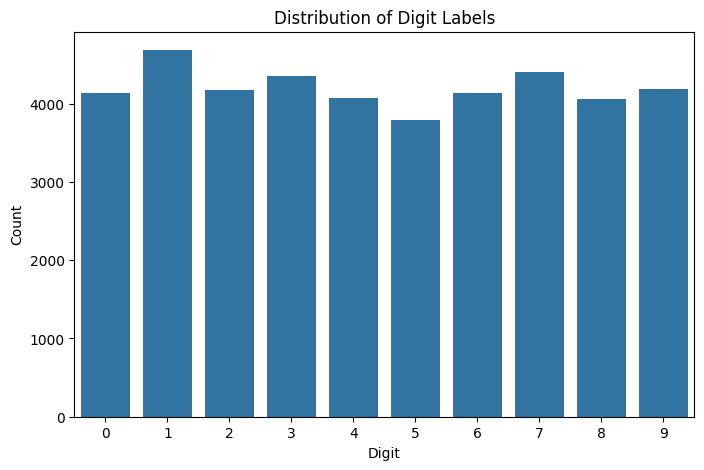

In [31]:
plt.figure(figsize=(8,5))
sns.countplot(x=train["label"])
plt.title("Distribution of Digit Labels")
plt.xlabel("Digit")
plt.ylabel("Count")
plt.show()

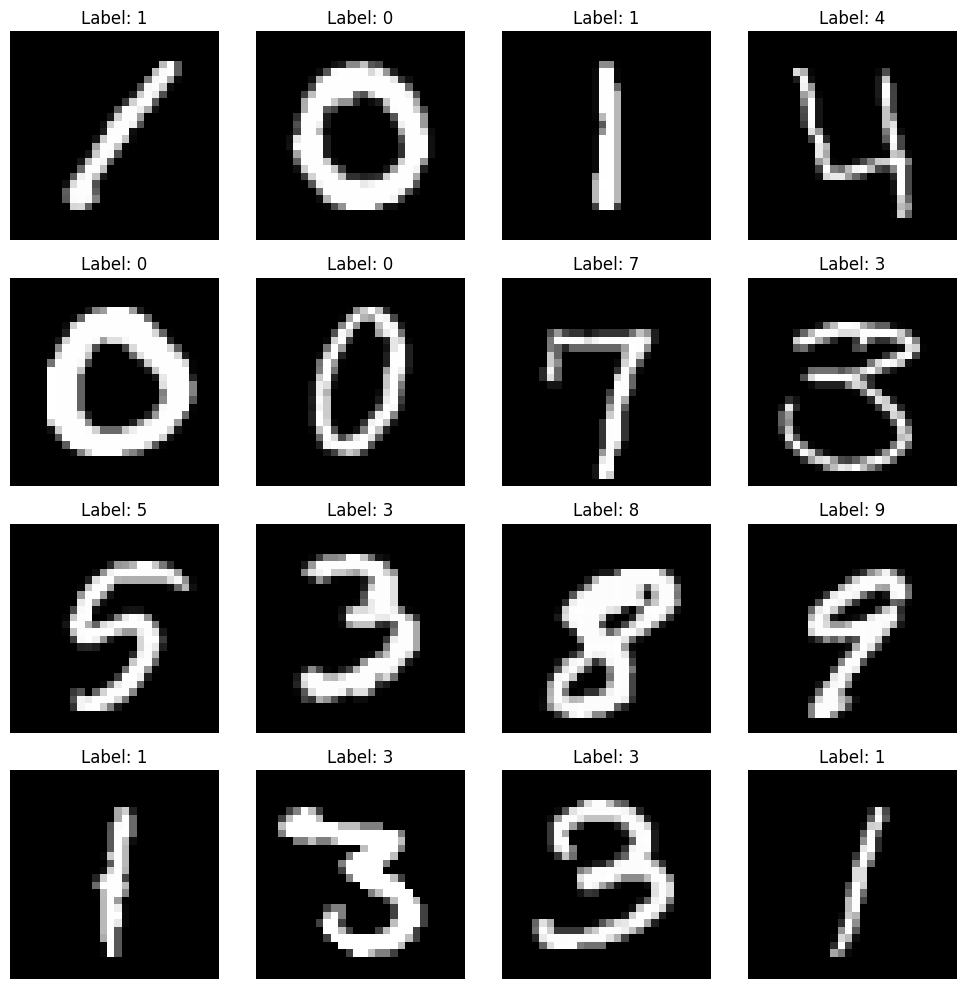

In [11]:
plt.figure(figsize=(10,10))

for i in range(16):
    plt.subplot(4, 4, i+1)
    image = train.iloc[i, 1:].values.reshape(28, 28)
    plt.imshow(image, cmap='gray')
    plt.title(f'Label: {train.iloc[i, 0]}')
    plt.axis("off")

plt.tight_layout()
plt.show()

In [32]:
X = train.drop("label", axis=1).values
y = train["label"].values

X_test = test.values

print("X shape: ", X.shape)
print("y shape: ", y.shape)
print("Test shape: ", X_test.shape)

X shape:  (42000, 784)
y shape:  (42000,)
Test shape:  (28000, 784)


In [33]:
# Normaliser les valeurs des pixels (de 0-255 à 0-1)
X = X / 255.0
X_test = X_test / 255.0

# On reshape les valeurs d'entrées pour qu'elles soient valides pour le CNN
X = X.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

print(f'Reshaped X: {X.shape}')
print(f'Reshaped Test: {X_test.shape}')

Reshaped X: (42000, 28, 28, 1)
Reshaped Test: (28000, 28, 28, 1)


In [34]:
y = to_categorical(y, num_classes=10)

print(f'One-hot encoded y shape: {y.shape}')

One-hot encoded y shape: (42000, 10)


In [37]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.1, random_state=42)

print(f'Training data shape: {X_train.shape}')
print(f'Validation date shape: {X_val.shape}')


Training data shape: (37800, 28, 28, 1)
Validation date shape: (4200, 28, 28, 1)


In [53]:
model = Sequential()

model.add(Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(10, activation='softmax'))

model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [54]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [55]:
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=128,
    validation_data=(X_val, y_val),
    verbose=1
)

Epoch 1/10
296/296 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.9003 - loss: 0.3311 - val_accuracy: 0.9719 - val_loss: 0.0878
Epoch 2/10
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9731 - loss: 0.0880 - val_accuracy: 0.9800 - val_loss: 0.0618
Epoch 3/10
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9815 - loss: 0.0626 - val_accuracy: 0.9833 - val_loss: 0.0507
Epoch 4/10
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9844 - loss: 0.0514 - val_accuracy: 0.9857 - val_loss: 0.0459
Epoch 5/10
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9865 - loss: 0.0429 - val_accuracy: 0.9871 - val_loss: 0.0397
Epoch 6/10
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9885 - loss: 0.0360 - val_accuracy: 0.9888 - val_loss: 0.0377
Epoch 7/10
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9894 - loss: 0.0313 - val_accuracy: 0.9876 - val_loss: 0.0380
Epoch 8/10
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9915 - loss: 0.0267 - val_accuracy: 0

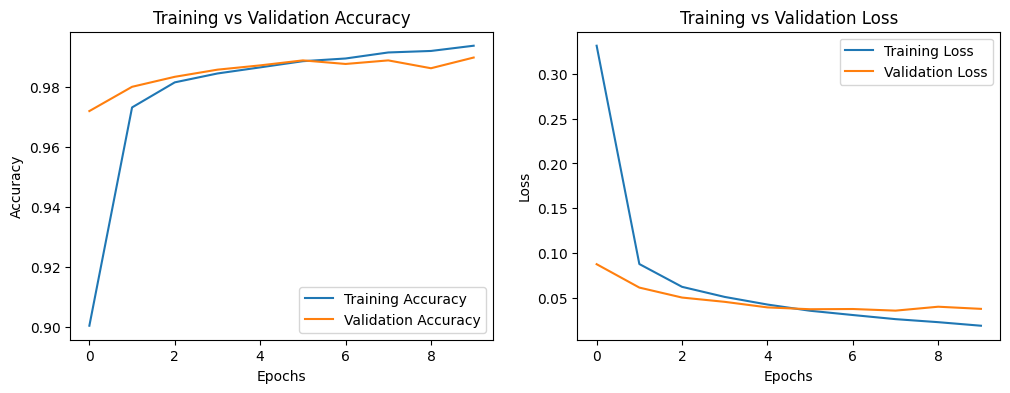

In [56]:
plt.figure(figsize=(12,4))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.show()

In [64]:
# Predict on validation set
y_val_pred = np.argmax(model.predict(X_val), axis=1)
y_val_true = np.argmax(y_val, axis=1)

wrong_indices = np.where(y_val_pred != y_val_true)[0]

print("Number of incorrect predictions on 4200:", len(wrong_indices))

132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Number of incorrect predictions on 4200: 43


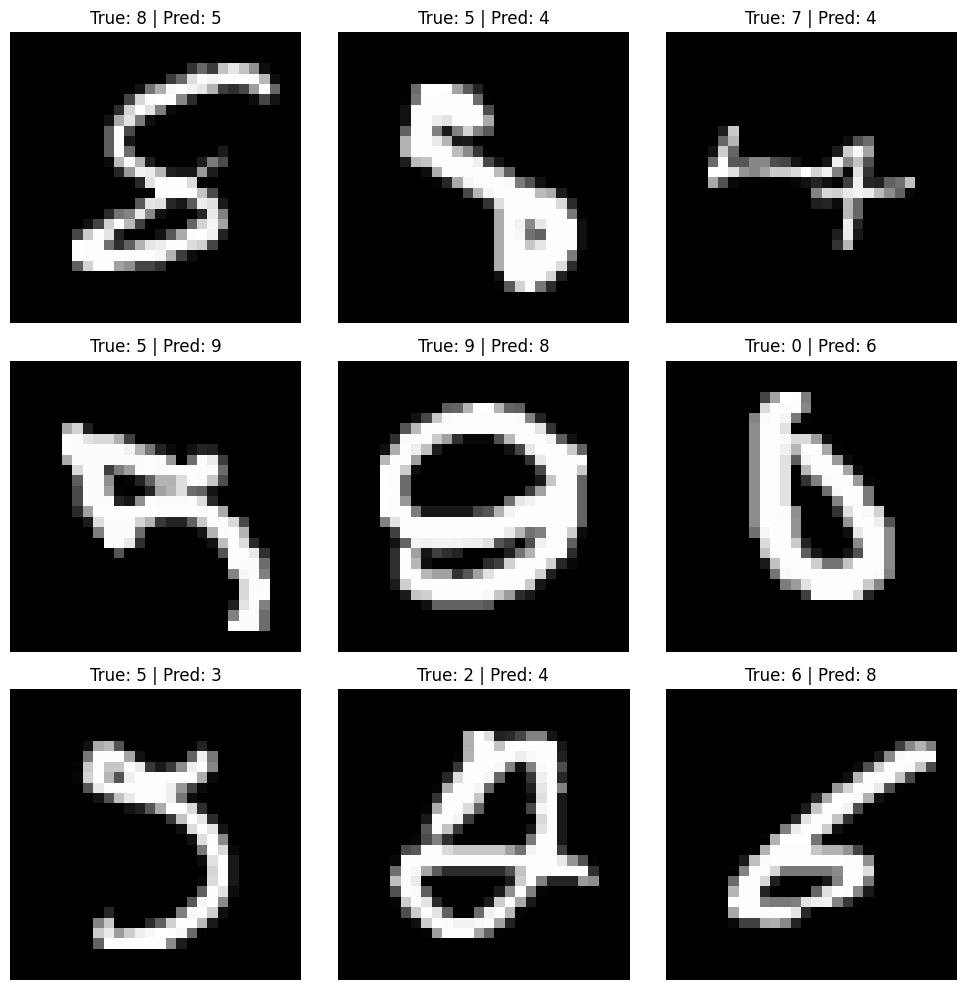

In [66]:
plt.figure(figsize=(10,10))

for i, idx in enumerate(wrong_indices[:9]):
    plt.subplot(3,3,i+1)
    plt.imshow(X_val[idx].reshape(28,28), cmap='gray')
    plt.title(f"True: {y_val_true[idx]} | Pred: {y_val_pred[idx]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [70]:
test_predictions = np.argmax(model.predict(X_test), axis=1)

print("Test predictions shape:", test_predictions.shape)

875/875 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Test predictions shape: (28000,)


In [74]:
submission = pd.DataFrame({
    "ImageId": np.arange(1, len(test_predictions) + 1),
    "Label": test_predictions
})

submission.to_csv("submission.csv", index=False)

submission.head()

,ImageId,Label
0,1,2
1,2,0
2,3,9
3,4,9
4,5,3
